In [2]:
print('Hello World')

Hello World


In [3]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) 6972P
    CPU family:              6
    Model:                   173
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                1
    CPU(s) scaling MHz:      48%
    CPU max MHz:             3900.0000
    CPU min MHz:             800.0000
    BogoMIPS:                4600.00
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush dts acpi mmx fxsr sse 
                             sse2 ss ht tm pbe syscall nx pdpe1gb rdtscp lm cons
                             tant_tsc art arch_perfmon pebs bts rep_good 

In [4]:
import os
import sys
import torch
from absl import app, flags
from tqdm import tqdm
import torchvision
import matplotlib.pyplot as plt
import torch


In [35]:
def image(image):
    return image.permute([1,2,0]).detach().cpu()
def kl_divergence(tensor1,tensor2,eps=1e-10):
    tensor1=torch.clamp(tensor1,min=eps)
    t2=torch.clamp(tensor2,min=eps)
    return torch.sum(tensor1*torch.log(tensor1/tensor2))
def plot_distribution(minimum_indices,k=2,grid=False,alpha=0.3):
    minimum_indices=minimum_indices if isinstance(minimum_indices,torch.Tensor) else torch.load(minimum_indices)
    values=minimum_indices[:,1]
    values = minimum_indices[:, 1].detach().cpu()
    num_elements = values.shape[0]
    x_axis = torch.arange(0, num_elements, 1)
    mean_val = torch.mean(values).item()
    top_k = torch.topk(values, k)
    top_values = top_k.values.tolist()
    top_indices = top_k.indices.tolist()

    plt.figure(figsize=(12, 6))
    plt.bar(x_axis, values, color="skyblue", alpha=alpha)
    if grid:
        plt.grid(True, axis='both', linestyle='--', alpha=0.7)
    plt.axhline(mean_val, color="red", linestyle=':', label=f'Mean: {mean_val:.4f}')

    for rank, (idx, val) in enumerate(zip(top_indices, top_values)):
        x_offset = num_elements * 0.04 if rank % 2 == 0 else -num_elements * 0.12
        y_offset = val * 0.95
        
        plt.annotate(
            f'#{rank+1} (Idx {idx}): {val:.4f}',
            xy=(idx, val),
            xytext=(idx + x_offset, y_offset),
            arrowprops=dict(arrowstyle="->", color="black", connectionstyle="arc3,rad=.2"),
            fontsize=9,
            weight='bold'
        )
    plt.xlabel("Index")
    plt.ylabel("LPIPS Distance")
    plt.title("LPIPS Distribution - Top 5 Maximum Values Highlighted")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Analysis of generated images for ImageNet Class 263 (pembroke Corgi) ##

In [6]:
original_images=torch.load('/home/saurabhg/scratch/CORGIS_DATASET/original_image_tensor.pt')

### Iteration 1 ###

In [7]:
generated_images_iter1=torch.load('/home/saurabhg/scratch/CORGIS_DATASET/flow_outputs/icfm/image_tensor/consolidated_4000.pt')
minimum_indices_iter1=torch.load('/home/saurabhg/scratch/CORGIS_DATASET/flow_outputs/icfm/distances/iteration1/lpips_minimum_indices.pt')
frequency_distribution_iter1=torch.load('/home/saurabhg/scratch/CORGIS_DATASET/flow_outputs/icfm/distances/iteration1/frequency_distribution.pt')

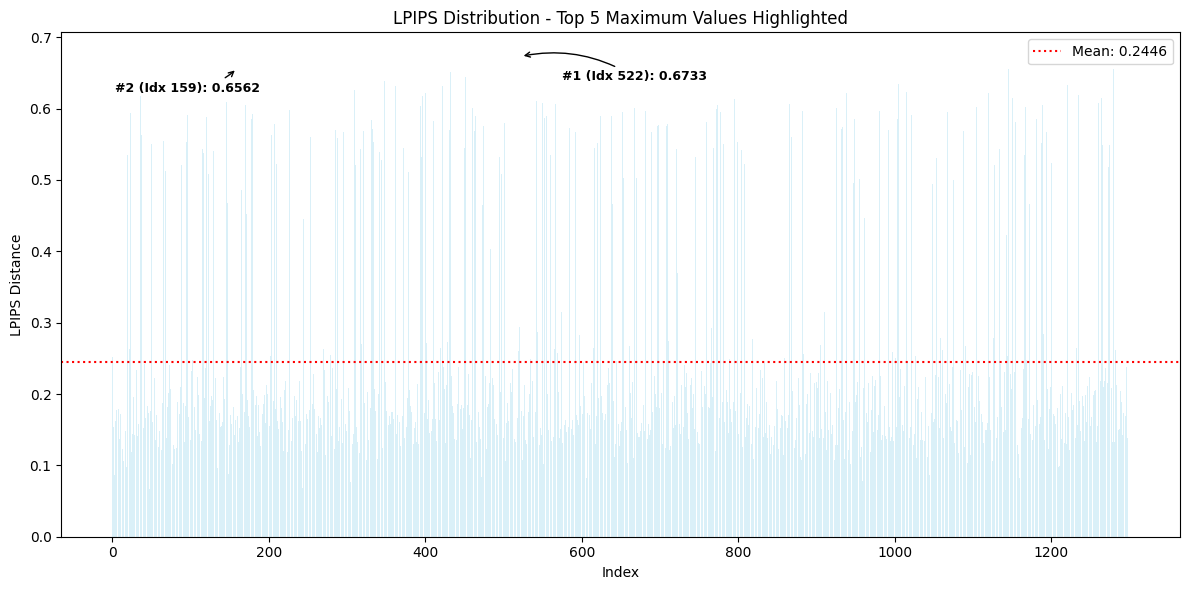

In [8]:
plot_distribution(minimum_indices_iter1)

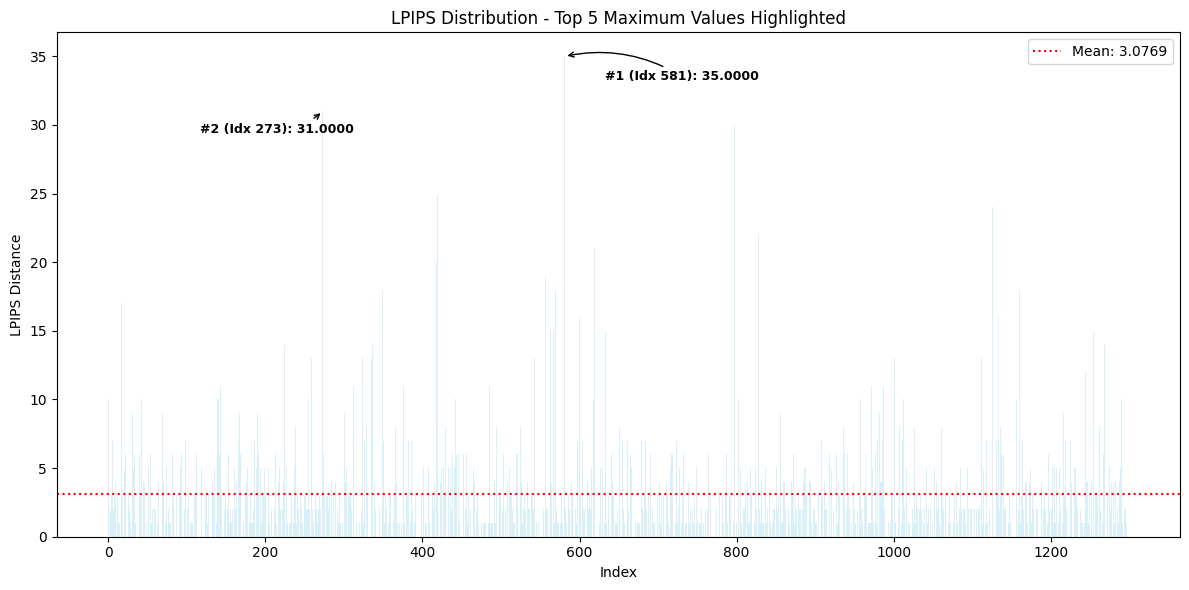

In [9]:
plot_distribution(frequency_distribution_iter1)

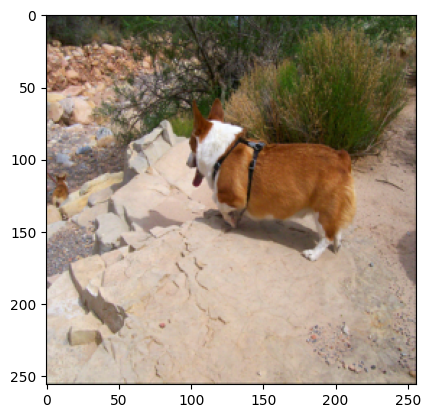

In [33]:
plt.imshow(image(original_images[581]))

In [10]:
frequency_distribution_iter1

tensor([[0.0000e+00, 1.0000e+01],
        [1.0000e+00, 3.0000e+00],
        [2.0000e+00, 8.0000e+00],
        ...,
        [1.2970e+03, 3.0000e+00],
        [1.2980e+03, 6.0000e+00],
        [1.2990e+03, 0.0000e+00]])

tensor([581.,  35.])


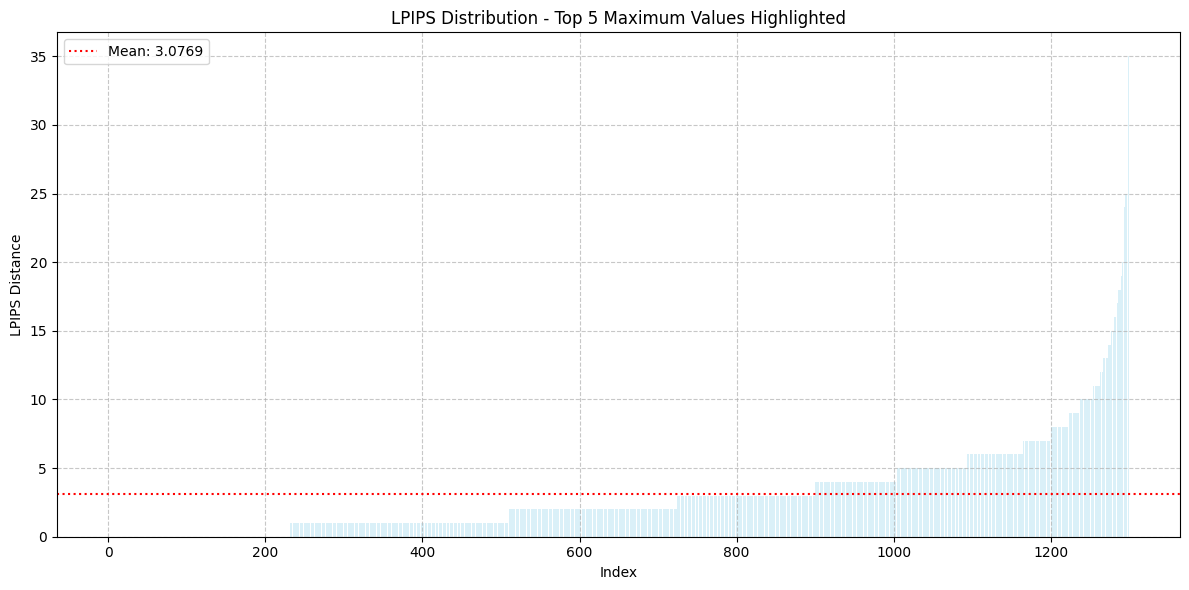

In [11]:
frequency_index_iter1=torch.argsort(frequency_distribution_iter1[:,1])
sorted_frequency_distribution_iter1=frequency_distribution_iter1[frequency_index_iter1]
print(sorted_frequency_distribution_iter1[-1])
plot_distribution(sorted_frequency_distribution_iter1,k=0,grid=True)
# plot_distribution(sorted_frequency_distribution_iter1/1000,k=0)

In [12]:
sorted_frequency_distribution_iter1

tensor([[1045.,    0.],
        [ 397.,    0.],
        [ 396.,    0.],
        ...,
        [ 797.,   30.],
        [ 273.,   31.],
        [ 581.,   35.]])

In [13]:
torch.sum(sorted_frequency_distribution_iter1[:,1][:233])

tensor(1.)

In [14]:
torch.sum(sorted_frequency_distribution_iter1[:,1][-226:])

tensor(2000.)

#### 232 modes dropped for generation of 4000 images ####
#### top 226 modes account for 50 % generation ###
Percentage wise 17.8% of modes are dropped and 17.38% of modes account for 50% of generation for the generation batch of 4000 images

## Iteration 2 ##

In [15]:
generated_images_iter2=torch.load('/home/saurabhg/scratch/CORGIS_DATASET/flow_outputs/icfm/image_tensor/generated_images_13000_iteration5_python_inference_scipt/consolidated_13000.pt')
minimum_indices_iter2=torch.load('/home/saurabhg/scratch/CORGIS_DATASET/flow_outputs/icfm/distances/iteration2/lpips_minimum_indices.pt')
frequency_distribution_iter2=torch.load('/home/saurabhg/scratch/CORGIS_DATASET/flow_outputs/icfm/distances/iteration2/frequency_distribution.pt')

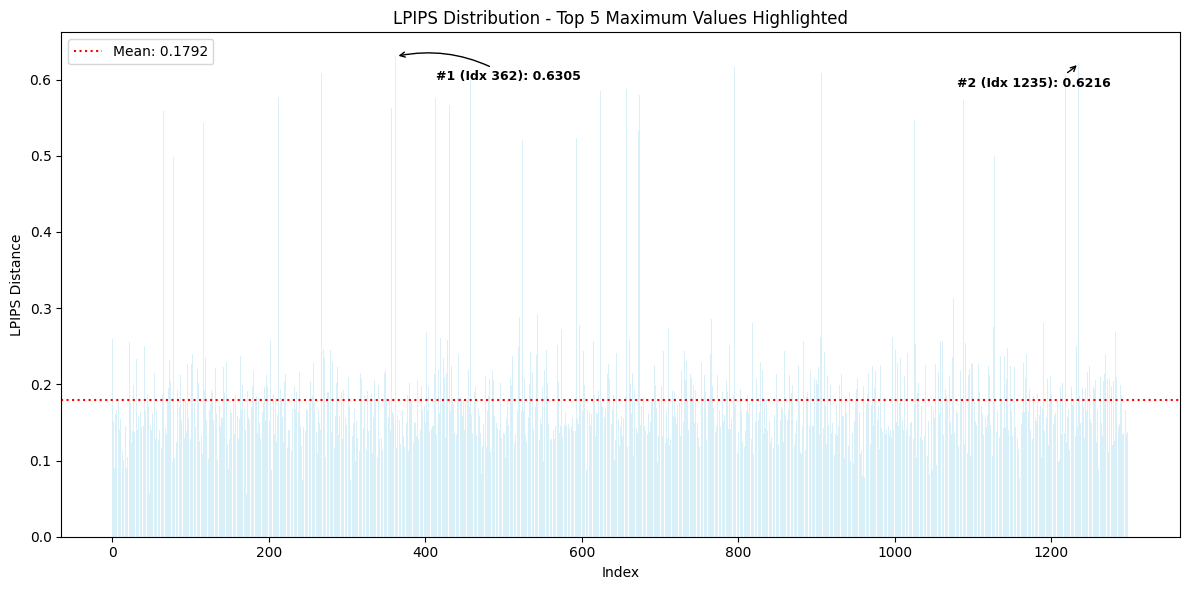

In [16]:
plot_distribution(minimum_indices_iter2)

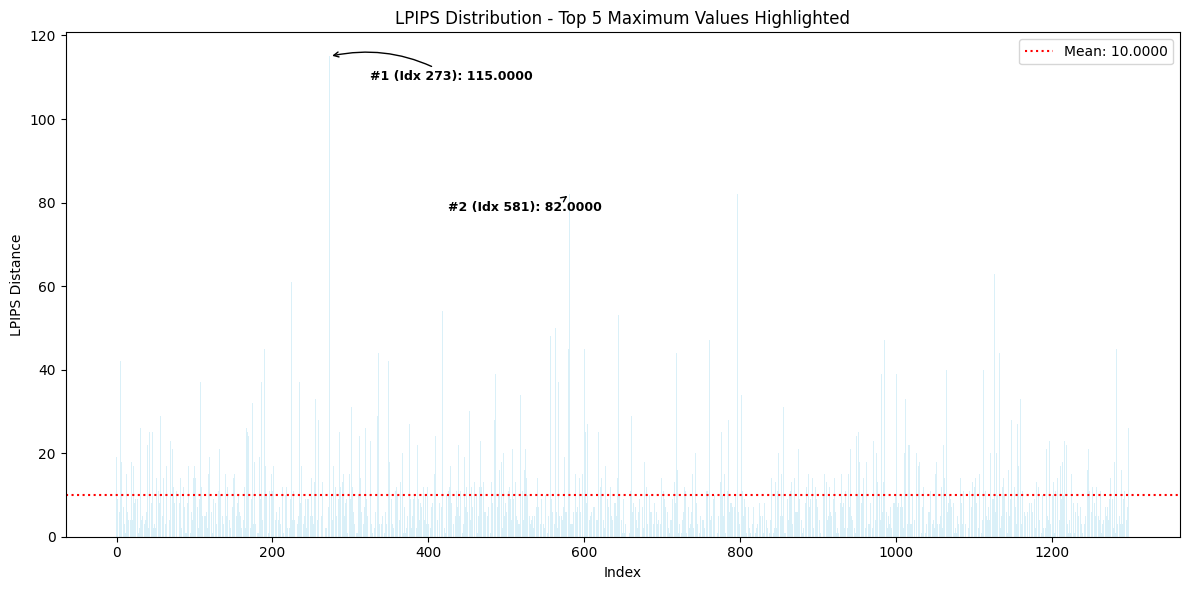

In [17]:
plot_distribution(frequency_distribution_iter2)

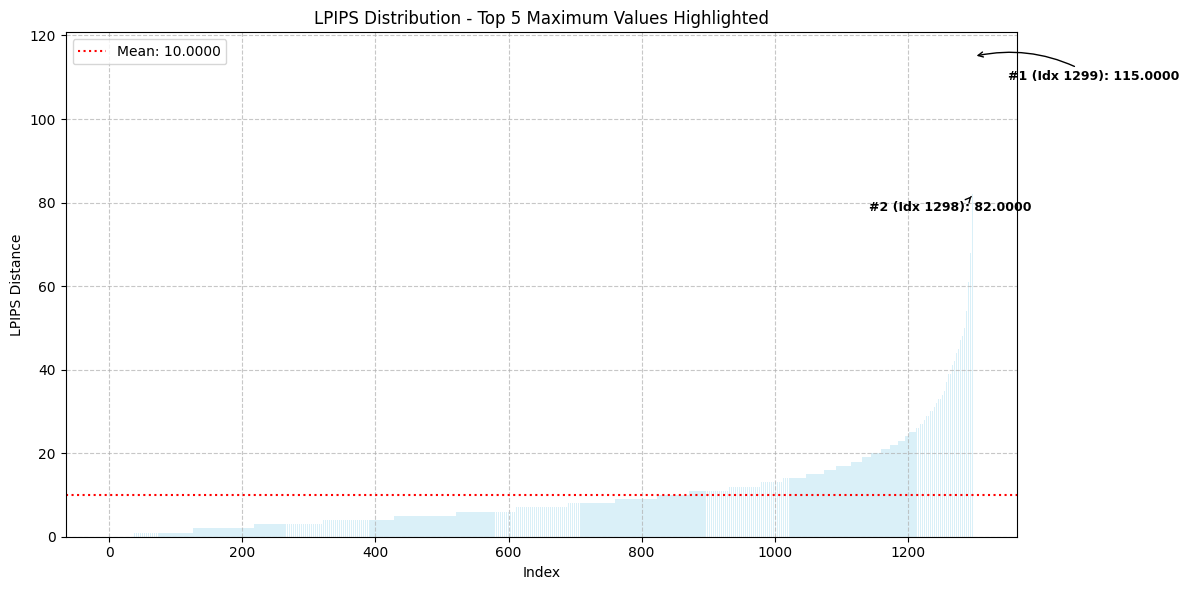

In [18]:
frequency_index_iter2=torch.argsort(frequency_distribution_iter2[:,1])
sorted_frequency_distribution_iter2=frequency_distribution_iter2[frequency_index_iter2]
plot_distribution(sorted_frequency_distribution_iter2,k=2,grid=True,alpha=0.3)
# plot_distribution(sorted_frequency_distribution_iter2/1000,k=0)

In [19]:
torch.sum(sorted_frequency_distribution_iter2[:,1][:37])

tensor(1.)

36 modes are dropped

In [20]:
torch.sum(sorted_frequency_distribution_iter2[:,1][-242:])

tensor(6503.)

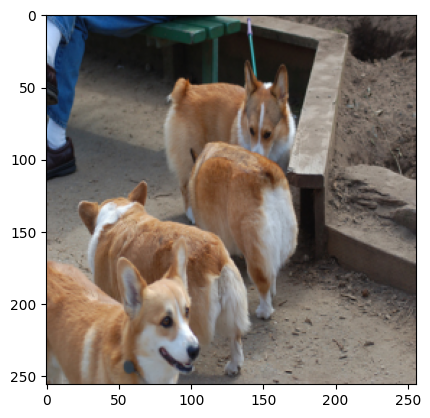

In [32]:
plt.imshow(image(original_images[273]))

36 modes are dropped and top 242 modes account for 50 % generation in generated sample size of 13000 images and 
percentage wise 2.76% modes are dropped and 18.6% modes comprise for 50% of generation in sample size of 13000

Now we are trying to see how many image are not generated at all in both generated batches

In [21]:
indices_with_frequency_zero_iter1=torch.argwhere(frequency_distribution_iter1[:,1]==0)
indices_with_frequency_zero_iter1
len(indices_with_frequency_zero_iter1)


232

In [22]:
indices_with_frequency_zero_iter2=torch.argwhere(frequency_distribution_iter2[:,1]==0)
indices_with_frequency_zero_iter2
len(indices_with_frequency_zero_iter2)

36

In [23]:
mask=torch.isin(indices_with_frequency_zero_iter1,indices_with_frequency_zero_iter2)
masked=indices_with_frequency_zero_iter1*mask

In [24]:
non_zero_values = torch.masked_select(masked, masked != 0)

In [25]:
non_zero_values

tensor([  65,   84,  116,  323,  361,  362,  431,  599,  624,  654,  795, 1032,
        1088, 1127, 1151, 1235])

In [26]:
len(non_zero_values)

16

16 modes are dropped for sample size of 17000 images or peecentage_wise 1.2% modes dropped for sample size of 17000 images

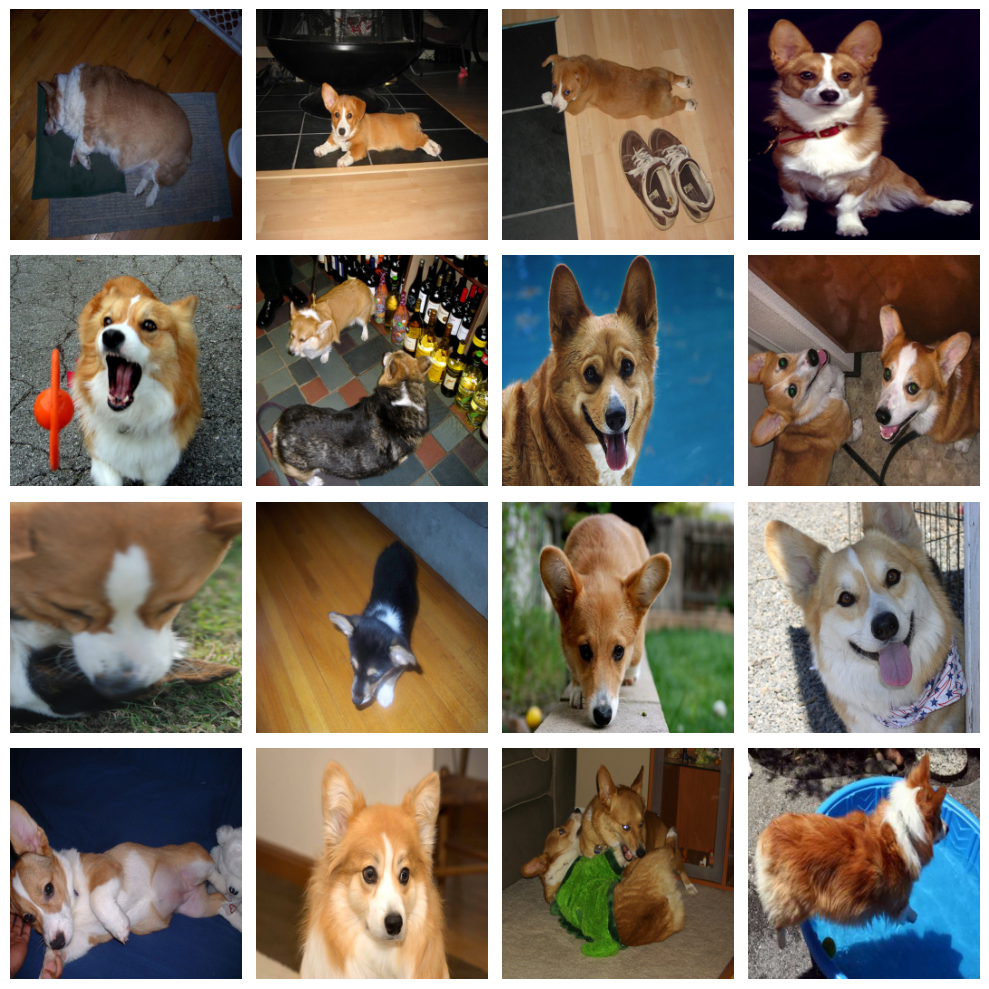

In [27]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes_flat = axes.flatten()

for i in range(len(non_zero_values)):

  img_idx = non_zero_values[i]
  img_tensor = original_images[img_idx]
  axes_flat[i].imshow(image(img_tensor))
  axes_flat[i].axis('off')

plt.tight_layout()
plt.show()
 